#Group Alpha - Stock Market Analysis

Rohan Madhur

Matthew Woods

Antonio Sanders

Derek Eodice


Denzel Thomas


Najah Bell

# Part 1: Stock Price Analysis and Forecasting

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import date

## Stock Indicies Analysis

In [ ]:
# Set the Tickers
dow ="^DJI"
nasdaq ="^IXIC"
russell ="^RUT"
sp500 ="^GSPC"

# Set start and end dates
start_date = "2023-01-01"
end_date = date.today() #This makes the date dynamic so that we don't have to keep resetting it.

dow_data = yf.download(dow, start=start_date, end=end_date)
nasdaq_data = yf.download(nasdaq, start=start_date, end=end_date)
russell_data = yf.download(russell, start=start_date, end=end_date)
sp500_data = yf.download(sp500, start=start_date, end=end_date)

/tmp/ipython-input-2946683035.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dow_data = yf.download(dow, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2946683035.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nasdaq_data = yf.download(nasdaq, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2946683035.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  russell_data = yf.download(russell, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2946683035.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500_data = yf.download(sp500, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 complete

In [ ]:
def data_check(df, name):
    print(name)

    # Check for missing values
    print("Missing values:\n", df.isnull().sum())

    # Check if the index is datetime
    print("\nIndex type:", type(df.index))

    # Check if the index is sorted
    print("Index sorted?:", df.index.is_monotonic_increasing)

    # Check for duplicate dates
    print("Duplicate dates?:", df.index.duplicated().any())

    # View the first rows
    print("\nPreview:")
    display(df.head())
    print("\n")

data_check(dow_data, "Dow Jones")
data_check(nasdaq_data, "Nasdaq")
data_check(russell_data, "Russell 2000")
data_check(sp500_data, "S&P 500")


Dow Jones
Missing values:
 Price   Ticker
Close   ^DJI      0
High    ^DJI      0
Low     ^DJI      0
Open    ^DJI      0
Volume  ^DJI      0
dtype: int64

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index sorted?: True
Duplicate dates?: False

Preview:


Price,Close,High,Low,Open,Volume
Ticker,^DJI,^DJI,^DJI,^DJI,^DJI
Date,,,,,
2023-01-03,33136.371094,33387.519531,32850.570312,33148.898438,355930000
2023-01-04,33269.769531,33409.101562,33033.480469,33165.140625,379400000
2023-01-05,32930.078125,33191.718750,32812.328125,33191.718750,337920000
2023-01-06,33630.609375,33710.660156,32997.390625,33055.300781,360740000
2023-01-09,33517.648438,33935.109375,33487.660156,33664.390625,327840000




Nasdaq
Missing values:
 Price   Ticker
Close   ^IXIC     0
High    ^IXIC     0
Low     ^IXIC     0
Open    ^IXIC     0
Volume  ^IXIC     0
dtype: int64

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index sorted?: True
Duplicate dates?: False

Preview:


Price,Close,High,Low,Open,Volume
Ticker,^IXIC,^IXIC,^IXIC,^IXIC,^IXIC
Date,,,,,
2023-01-03,10386.980469,10613.059570,10309.160156,10562.059570,4780650000
2023-01-04,10458.759766,10515.219727,10337.639648,10467.820312,5085380000
2023-01-05,10305.240234,10393.219727,10295.250000,10390.309570,4764270000
2023-01-06,10569.290039,10604.139648,10265.040039,10363.959961,5199780000
2023-01-09,10635.650391,10807.259766,10619.120117,10662.099609,5132190000




Russell 2000
Missing values:
 Price   Ticker
Close   ^RUT      0
High    ^RUT      0
Low     ^RUT      0
Open    ^RUT      0
Volume  ^RUT      0
dtype: int64

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index sorted?: True
Duplicate dates?: False

Preview:


Price,Close,High,Low,Open,Volume
Ticker,^RUT,^RUT,^RUT,^RUT,^RUT
Date,,,,,
2023-01-03,1750.729980,1785.949951,1737.260010,1769.750000,3959140000
2023-01-04,1772.540039,1781.969971,1758.089966,1758.089966,4414080000
2023-01-05,1753.189941,1766.079956,1745.380005,1766.079956,3893450000
2023-01-06,1792.800049,1795.560059,1758.500000,1764.329956,3923560000
2023-01-09,1795.910034,1817.089966,1794.540039,1801.069946,4311770000




S&P 500
Missing values:
 Price   Ticker
Close   ^GSPC     0
High    ^GSPC     0
Low     ^GSPC     0
Open    ^GSPC     0
Volume  ^GSPC     0
dtype: int64

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index sorted?: True
Duplicate dates?: False

Preview:


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2023-01-03,3824.139893,3878.459961,3794.330078,3853.290039,3959140000
2023-01-04,3852.969971,3873.159912,3815.770020,3840.360107,4414080000
2023-01-05,3808.100098,3839.739990,3802.419922,3839.739990,3893450000
2023-01-06,3895.080078,3906.189941,3809.560059,3823.370117,3923560000
2023-01-09,3892.090088,3950.570068,3890.419922,3910.820068,4311770000


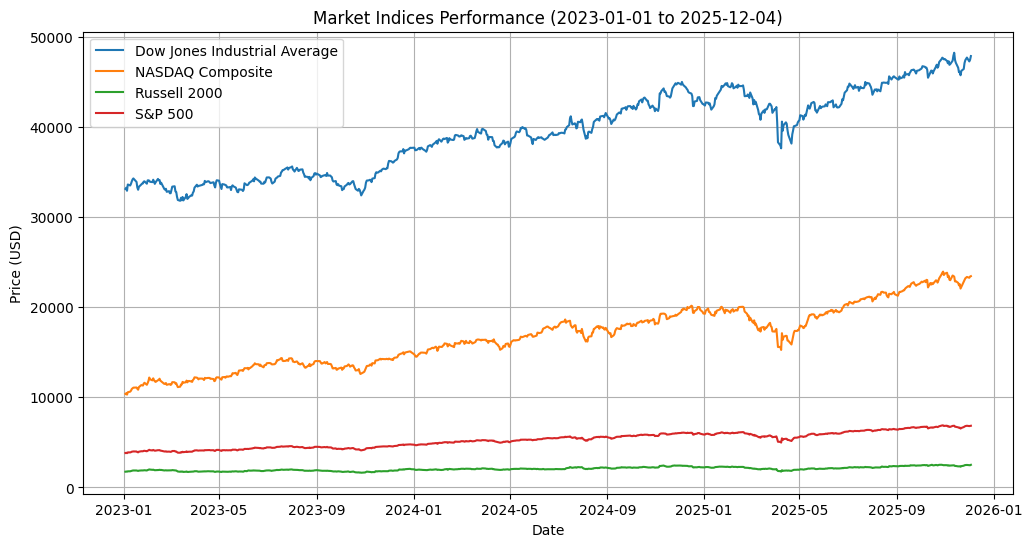

In [ ]:
# Add plot titles and labels
plt.figure(figsize=(12, 6))
plt.plot(dow_data['Close'], label='Dow Jones Industrial Average')
plt.plot(nasdaq_data['Close'], label='NASDAQ Composite')
plt.plot(russell_data['Close'], label='Russell 2000')
plt.plot(sp500_data['Close'], label='S&P 500')
plt.title(f'Market Indices Performance ({start_date} to {end_date})')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True) # Add a grid for easier reading
plt.legend() # Display the legend
plt.show()

In [ ]:
# Check the data types of the intitial data. We're going to convert to pandas for further analytics.

dow_data.dtypes
nasdaq_data.dtypes
russell_data.dtypes
sp500_data.dtypes

,,0
Price,Ticker,
Close,^GSPC,float64
High,^GSPC,float64
Low,^GSPC,float64
Open,^GSPC,float64
Volume,^GSPC,int64


In [ ]:
# Create pandas data frames for all indicies for scripting analytics
dow_df = pd.DataFrame(dow_data)
nasdaq_df = pd.DataFrame(nasdaq_data)
russell_df = pd.DataFrame(russell_data)

# Check your work by printing the data types of each dataframe
print(dow_df.dtypes)
print(nasdaq_df.dtypes)
print(russell_df.dtypes)

Price   Ticker
Close   ^DJI      float64
High    ^DJI      float64
Low     ^DJI      float64
Open    ^DJI      float64
Volume  ^DJI        int64
dtype: object
Price   Ticker
Close   ^IXIC     float64
High    ^IXIC     float64
Low     ^IXIC     float64
Open    ^IXIC     float64
Volume  ^IXIC       int64
dtype: object
Price   Ticker
Close   ^RUT      float64
High    ^RUT      float64
Low     ^RUT      float64
Open    ^RUT      float64
Volume  ^RUT        int64
dtype: object


In [ ]:
print(f"--- Dow Jones Industrial Average ---")
dow_lowest = dow_df[('Low', dow)].min()
dow_highest = dow_df[('High', dow)].max()
print(f"Lowest recorded level: {dow_lowest:.2f}")
print(f"Highest recorded level: {dow_highest:.2f}")
print(f"Difference: {dow_highest - dow_lowest:.2f} points\n")

print(f"--- NASDAQ Composite ---")
nasdaq_lowest = nasdaq_df[('Low', nasdaq)].min()
nasdaq_highest = nasdaq_df[('High', nasdaq)].max()
print(f"Lowest recorded level: {nasdaq_lowest:.2f}")
print(f"Highest recorded level: {nasdaq_highest:.2f}")
print(f"Difference: {nasdaq_highest - nasdaq_lowest:.2f} points\n")

print(f"--- Russell 2000 ---")
russell_lowest = russell_df[('Low', russell)].min()
russell_highest = russell_df[('High', russell)].max()
print(f"Lowest recorded level: {russell_lowest:.2f}")
print(f"Highest recorded level: {russell_highest:.2f}")
print(f"Difference: {russell_highest - russell_lowest:.2f} points\n")

print(f"--- S&P 500 ---")
sp500_lowest = sp500_data[('Low', sp500)].min()
sp500_highest = sp500_data[('High', sp500)].max()
print(f"Lowest recorded level: {sp500_lowest:.2f}")
print(f"Highest recorded level: {sp500_highest:.2f}")
print(f"Difference: {sp500_highest - sp500_lowest:.2f} points")

--- Dow Jones Industrial Average ---
Lowest recorded level: 31429.82
Highest recorded level: 48431.57
Difference: 17001.75 points

--- NASDAQ Composite ---
Lowest recorded level: 10265.04
Highest recorded level: 24019.99
Difference: 13754.95 points

--- Russell 2000 ---
Lowest recorded level: 1633.67
Highest recorded level: 2541.67
Difference: 908.00 points

--- S&P 500 ---
Lowest recorded level: 3794.33
Highest recorded level: 6920.34
Difference: 3126.01 points


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


indicies = ['DJIA', 'NASDAQ ', 'Russell 2K', 'S&P 500']

russel_difference = russell_highest - russell_lowest
nasdaq_difference = nasdaq_highest - nasdaq_lowest
dow_difference = dow_highest - dow_lowest
sp500_difference = sp500_highest - sp500_lowest

differences = (dow_difference, nasdaq_difference, russel_difference, sp500_difference)
differences = np.array(differences).round(2)

# difference_df = pd.DataFrame({
#     "Russell 2000": russel_difference,
#     "NASDAQ Composite": nasdaq_difference,
#     "Dow Jones Industrial Average": dow_difference,
#     "S&P 500": sp500_difference
# })

difference_df = pd.DataFrame({'Index': indicies,
                              'Difference': differences})

print(difference_df)
print(difference_df.dtypes)

        Index  Difference
0        DJIA    17001.75
1     NASDAQ     13754.95
2  Russell 2K      908.00
3     S&P 500     3126.01
Index          object
Difference    float64
dtype: object


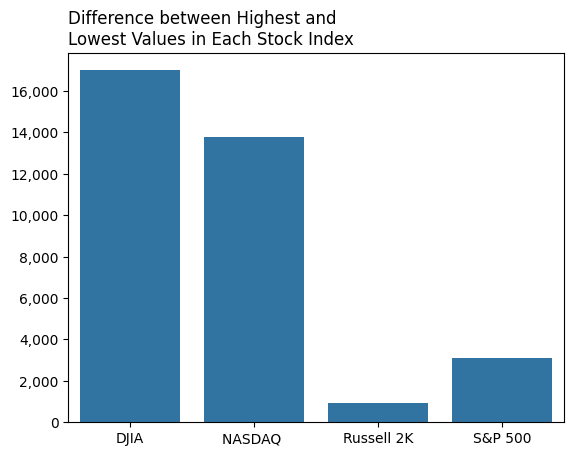

The difference beween the highest index and lowest index is 16093.75.
The row with the higest difference is DJIA, with a value of 17001.75.
The row with the lowest difference is Russell 2K, with a value of 908.0.


In [ ]:
import matplotlib.ticker as mticker
sns.barplot(data = difference_df,
            x = 'Index',
            y = 'Difference')
plt.xlabel("")
plt.ylabel("")
plt.title("Difference between Highest and\nLowest Values in Each Stock Index",
          loc='left')
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

iloc_diff_max = difference_df['Difference'].idxmax()
iloc_diff_min = difference_df['Difference'].idxmin()

highest_diff = difference_df.iloc[iloc_diff_max]
lowest_diff = difference_df.iloc[iloc_diff_min]

print(f"The difference beween the highest index and lowest index is {difference_df['Difference'].max() - difference_df['Difference'].min()}.")
print(f"The row with the higest difference is {highest_diff['Index']}, with a value of {highest_diff['Difference']}.")
print(f"The row with the lowest difference is {lowest_diff['Index']}, with a value of {lowest_diff['Difference']}.")

## Time Series Analysis

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Select closing prices
dow_close = dow_data['Close'].copy()
nasdaq_close = nasdaq_data['Close'].copy()
russell_close = russell_data['Close'].copy()
sp500_close = sp500_data['Close'].copy()


dow_close.head()

Ticker,^DJI
Date,
2023-01-03,33136.371094
2023-01-04,33269.769531
2023-01-05,32930.078125
2023-01-06,33630.609375
2023-01-09,33517.648438


**Fit ETS Model**

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


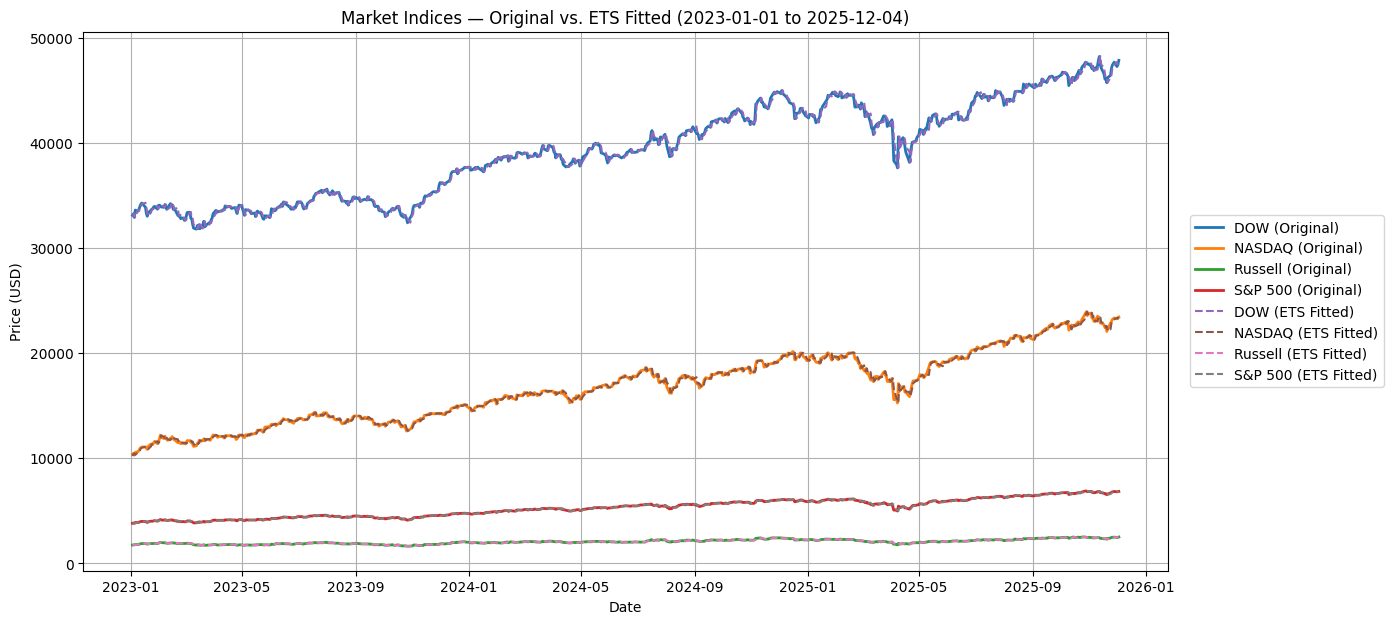

In [ ]:
# Fit ETS models
ets_dow_model     = ExponentialSmoothing(dow_close,     trend='add', seasonal=None).fit()
ets_nasdaq_model  = ExponentialSmoothing(nasdaq_close,  trend='add', seasonal=None).fit()
ets_russell_model = ExponentialSmoothing(russell_close, trend='add', seasonal=None).fit()
ets_sp500_model   = ExponentialSmoothing(sp500_close,   trend='add', seasonal=None).fit()

# Extract fitted values
fitted_dow     = ets_dow_model.fittedvalues
fitted_nasdaq  = ets_nasdaq_model.fittedvalues
fitted_russell = ets_russell_model.fittedvalues
fitted_sp500   = ets_sp500_model.fittedvalues

plt.figure(figsize=(14, 7))

# Original prices
plt.plot(dow_close,     label='DOW (Original)',     linewidth=2)
plt.plot(nasdaq_close,  label='NASDAQ (Original)',  linewidth=2)
plt.plot(russell_close, label='Russell (Original)', linewidth=2)
plt.plot(sp500_close,   label='S&P 500 (Original)', linewidth=2)

# ETS fitted values
plt.plot(fitted_dow,     label='DOW (ETS Fitted)',     linestyle='--')
plt.plot(fitted_nasdaq,  label='NASDAQ (ETS Fitted)',  linestyle='--')
plt.plot(fitted_russell, label='Russell (ETS Fitted)', linestyle='--')
plt.plot(fitted_sp500,   label='S&P 500 (ETS Fitted)', linestyle='--')

plt.title(f'Market Indices — Original vs. ETS Fitted ({start_date} to {end_date})')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)
plt.show()

**Forecast Next 6 Months**

In [ ]:
# Forecast next 6 months (~126 trading days)
forecast_days = 126
ets_dow_forecast     = ets_dow_model.forecast(forecast_days)
ets_nasdaq_forecast  = ets_nasdaq_model.forecast(forecast_days)
ets_russell_forecast = ets_russell_model.forecast(forecast_days)
ets_sp500_forecast   = ets_sp500_model.forecast(forecast_days)

# Create future business dates starting from the next trading day
last_date = dow_close.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=forecast_days)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/u

**Plot Forecast**

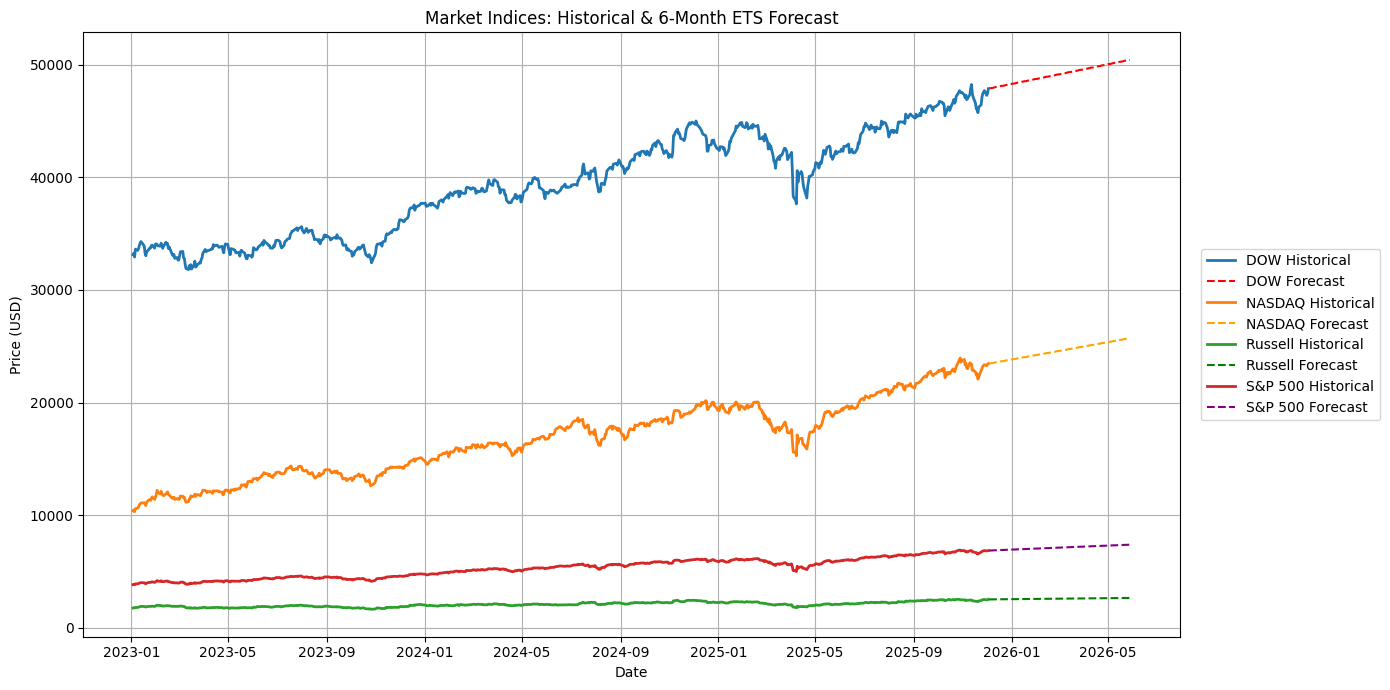

In [ ]:
plt.figure(figsize=(14, 7))

# --- DOW ---
plt.plot(dow_close.index, dow_close.values, label='DOW Historical', linewidth=2)
plt.plot(future_dates, ets_dow_forecast, label='DOW Forecast', color='red', linestyle='--')

# --- NASDAQ ---
plt.plot(nasdaq_close.index, nasdaq_close.values, label='NASDAQ Historical', linewidth=2)
plt.plot(future_dates, ets_nasdaq_forecast, label='NASDAQ Forecast', color='orange', linestyle='--')

# --- Russell 2000 ---
plt.plot(russell_close.index, russell_close.values, label='Russell Historical', linewidth=2)
plt.plot(future_dates, ets_russell_forecast, label='Russell Forecast', color='green', linestyle='--')

# --- S&P 500 ---
plt.plot(sp500_close.index, sp500_close.values, label='S&P 500 Historical', linewidth=2)
plt.plot(future_dates, ets_sp500_forecast, label='S&P 500 Forecast', color='purple', linestyle='--')

plt.title(f'Market Indices: Historical & 6-Month ETS Forecast')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)

# Legend outside on the right
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.tight_layout()
plt.show()



# Part 2: Text Scraping Web Articles About the Stock Indicies

In [ ]:
import pandas as pd
import numpy as np
import nltk
nltk.download('vader_lexicon')
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import PlaintextCorpusReader
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import string
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
from urllib import request


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## Dow Jones text mining

In [ ]:
import urllib.request
import bs4 as bs

dow = urllib.request.urlopen('https://www.foxbusiness.com/markets/dow-soars-past-48000-first-time-history-amid-continuing-market-rally-surge-wednesday').read()

soup = bs.BeautifulSoup(dow, 'lxml') # object and parser

print(soup)

<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en-US%22%7D%7D" data-n-head-ssr="" lang="en-US">
<head>
<title>Dow Jones hits 17th record close of 2025, tops 48,000 for first time | Fox Business</title><meta content="IE=edge,chrome=1" data-n-head="ssr" http-equiv="X-UA-Compatible"/><meta content="width=device-width, initial-scale=1.0, minimum-scale=1.0" data-n-head="ssr" name="viewport"/><meta charset="utf-8" data-n-head="ssr"/><meta content="telephone=no" data-n-head="ssr" name="format-detection"/><meta content="//static.foxnews.com/static/orion/styles/img/fox-business/favicons/mstile-70x70.png" data-n-head="ssr" name="msapplication-square70x70logo"/><meta content="//static.foxnews.com/static/orion/styles/img/fox-business/favicons/mstile-150x150.png" data-n-head="ssr" name="msapplication-square150x150logo"/><meta content="//static.foxnews.com/static/orion/styles/img/fox-business/favicons/mstile-310x150.png" data-n-head="ssr" name="msapplication-wide310x150logo"/><meta

In [ ]:
print(soup.title) # Print the title...notice the tags

print(soup.title.string) # Print just the title string

print(soup.title.text)

<title>Dow Jones hits 17th record close of 2025, tops 48,000 for first time | Fox Business</title>
Dow Jones hits 17th record close of 2025, tops 48,000 for first time | Fox Business
Dow Jones hits 17th record close of 2025, tops 48,000 for first time | Fox Business


In [ ]:
# Now...try getting specific values

# First, get the paragraph
print("--Paragraph (w/ Tags)--")
print(soup.p)
# Now, get the paragraph text
print("\n--Paragraph Text--")
print(soup.p.text)

# Now, get all paragraphs
print("\n--All Paragraphs--")
print(soup.find_all('p'))

--Paragraph (w/ Tags)--
<p>
          Quotes displayed in real-time or delayed by at least 15 minutes. Market data provided by <a href="https://www.factset.com/">Factset</a>.
          Powered and implemented by <a href="https://www.factset.com/solutions/business-needs/digital-solutions">FactSet Digital Solutions</a>. 
            <a href="https://www.factset.com/privacy">Legal Statement</a>.
          </p>

--Paragraph Text--

          Quotes displayed in real-time or delayed by at least 15 minutes. Market data provided by Factset.
          Powered and implemented by FactSet Digital Solutions. 
            Legal Statement.
          

--All Paragraphs--
[<p>
          Quotes displayed in real-time or delayed by at least 15 minutes. Market data provided by <a href="https://www.factset.com/">Factset</a>.
          Powered and implemented by <a href="https://www.factset.com/solutions/business-needs/digital-solutions">FactSet Digital Solutions</a>. 
            <a href="https://www.fact

['Quotes', 'displayed', 'in', 'real', '-', 'time', 'or', 'delayed', 'by', 'at', 'least', '15', 'minutes', '.', 'Market', 'data', 'provided', 'byFactset', '.', 'Powered', 'and', 'implemented', 'byFactSet', 'Digital', 'Solutions', '.', 'Legal', 'Statement', '.', 'This']


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


[('market', 7), ('news', 6), ('data', 5), ('fox', 5), ('year', 5), ('byfactset', 4), ('ceo', 4), ('ai', 4), ('record', 4), ('investors', 4)]


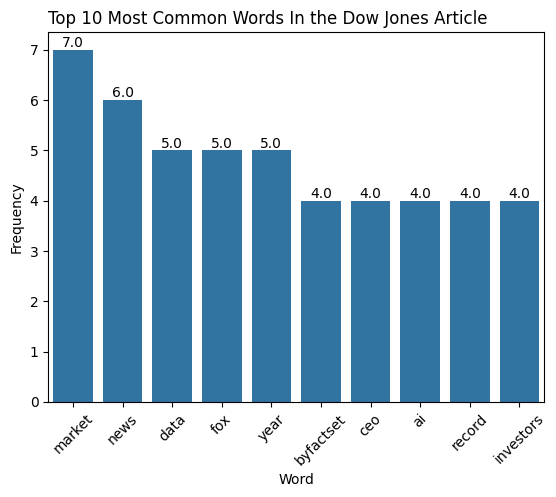

In [ ]:
import string
# Step 1: Extract text from paragraph tags

paragraphs = soup.find_all('p')
text_list = [p.get_text(strip=True) for p in paragraphs]

# Step 2: Combine paragraphs into a single document
dow_full = " ".join(text_list)

# Step 3: Work directly with the tokens
import os
from nltk.corpus import PlaintextCorpusReader

## Save to a local text file
with open("dow_article.txt", "w", encoding="utf-8") as f:
    f.write(dow_full)

## Create a corpus folder (optional)
corpus_root = './'
corpus = PlaintextCorpusReader(corpus_root, 'dow_article.txt')

## Now, check the stopwords
words = corpus.words()
print(words[:30])

# Download the punkt_tab resource
nltk.download('punkt_tab')

# Step 4: Tokenize
tokens = word_tokenize(dow_full)

# Step 5: Convert all tokens to lowercase, remove stopwords and puncutation
stop_words = set(stopwords.words("english"))
punct = set(string.punctuation)

# Step 5a: create the clean_tokens list
clean_tokens = [
    t.lower() for t in tokens
    if t.lower() not in stop_words and t not in punct and t.isalpha()
]

# Step 6: Count word frequencies
freqs = Counter(clean_tokens)

# Step 7: Get the top 10 most freuqent words and perform EDA
dow_top_10 = freqs.most_common(10)

print(dow_top_10)

# Get the top 10 words into a pandas dataframe for data visualization
dow_df = pd.DataFrame(dow_top_10, columns=['Word', 'Frequency'])

# Create a bar plot of the 10 most common words
ax = sns.barplot(x='Word', y='Frequency', data=dow_df)

# Rotate the x-axis labels for easier reading
ax.tick_params(axis='x', rotation=45)

# Add data labels
for a in ax.patches:
    ax.annotate(f'{a.get_height()}',
                (a.get_x() + a.get_width() / 2., a.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')

plt.title('Top 10 Most Common Words In the Dow Jones Article', loc='left')
plt.show()

## Nasdaq Text Mining

In [ ]:
nasdaq = urllib.request.urlopen('https://www.foxbusiness.com/markets/stock-futures-trade-lower-following-nasdaq-rebound').read()

soup = bs.BeautifulSoup(nasdaq, 'lxml') # object and parser

print(soup)
print(soup.title) # Print the title...notice the tags

print(soup.title.string) # Print just the title string

print(soup.title.text)

# Now...try getting specific values

# First, get the paragraph
print("--Paragraph (w/ Tags)--")
print(soup.p)
# Now, get the paragraph text
print("\n--Paragraph Text--")
print(soup.p.text)

# Now, get all paragraphs
print("\n--All Paragraphs--")
print(soup.find_all('p'))

<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en-US%22%7D%7D" data-n-head-ssr="" lang="en-US">
<head>
<title>Stock futures trade mixed following Nasdaq rebound | Fox Business</title><meta content="IE=edge,chrome=1" data-n-head="ssr" http-equiv="X-UA-Compatible"/><meta content="width=device-width, initial-scale=1.0, minimum-scale=1.0" data-n-head="ssr" name="viewport"/><meta charset="utf-8" data-n-head="ssr"/><meta content="telephone=no" data-n-head="ssr" name="format-detection"/><meta content="//static.foxnews.com/static/orion/styles/img/fox-business/favicons/mstile-70x70.png" data-n-head="ssr" name="msapplication-square70x70logo"/><meta content="//static.foxnews.com/static/orion/styles/img/fox-business/favicons/mstile-150x150.png" data-n-head="ssr" name="msapplication-square150x150logo"/><meta content="//static.foxnews.com/static/orion/styles/img/fox-business/favicons/mstile-310x150.png" data-n-head="ssr" name="msapplication-wide310x150logo"/><meta content="//static

['Quotes', 'displayed', 'in', 'real', '-', 'time', 'or', 'delayed', 'by', 'at', 'least', '15', 'minutes', '.', 'Market', 'data', 'provided', 'byFactset', '.', 'Powered', 'and', 'implemented', 'byFactSet', 'Digital', 'Solutions', '.', 'Legal', 'Statement', '.', 'This']
[('market', 6), ('fox', 6), ('added', 6), ('tech', 5), ('byfactset', 4), ('news', 4), ('tuesday', 4), ('rise', 4), ('rose', 4), ('wall', 4)]


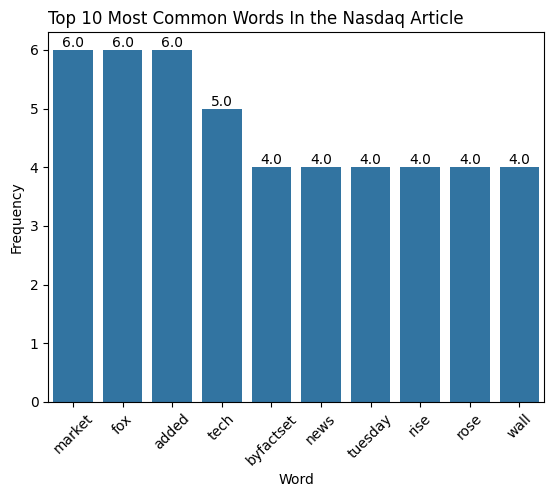

In [ ]:
# Take all paragraphs for the Nasdaq article, convert it into a corpus and get basic statistics
import string
# Step 1: Extract text from paragraph tags

paragraphs = soup.find_all('p')
text_list = [p.get_text(strip=True) for p in paragraphs]

# Step 2: Combine paragraphs into a single document
nasdaq_full = " ".join(text_list)

# Step 3: Work directly with the tokens
import os
from nltk.corpus import PlaintextCorpusReader

## Save to a local text file
with open("nasdaq_article.txt", "w", encoding="utf-8") as f:
    f.write(nasdaq_full)

## Create a corpus folder (optional)
corpus_root = './'
corpus = PlaintextCorpusReader(corpus_root, 'nasdaq_article.txt')

## Now, check the stopwords
words = corpus.words()
print(words[:30])

# Step 4: Tokenize
tokens = word_tokenize(nasdaq_full)

# Step 5: Convert all tokens to lowercase, remove stopwords and puncutation
stop_words = set(stopwords.words("english"))
punct = set(string.punctuation)

# Step 5a: create the clean_tokens list
clean_tokens = [
    t.lower() for t in tokens
    if t.lower() not in stop_words and t not in punct and t.isalpha()
]

# Step 6: Count word frequencies
freqs = Counter(clean_tokens)

# Step 7: Get the top 10 most freuqent words and perform EDA
nasdaq_top_10 = freqs.most_common(10)

print(nasdaq_top_10)

# Get the top 10 words into a pandas dataframe for data visualization
nasdaq_df = pd.DataFrame(nasdaq_top_10, columns=['Word', 'Frequency'])

# Create a bar plot of the 10 most common words
ax = sns.barplot(x='Word', y='Frequency', data=nasdaq_df)

# Rotate the x-axis labels for easier reading
ax.tick_params(axis='x', rotation=45)

# Add data labels
for a in ax.patches:
    ax.annotate(f'{a.get_height()}',
                (a.get_x() + a.get_width() / 2., a.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')

plt.title('Top 10 Most Common Words In the Nasdaq Article', loc='left')
plt.show()

## S&P Text Mining

In [ ]:
sp = urllib.request.urlopen('https://economictimes.indiatimes.com/news/international/us/sp-500-crash-sp-500-plunges-2-5-in-minutes-as-nvidia-rally-fades-and-bitcoin-crashes-why-us-stocks-reversed-after-early-gains-today/articleshow/125468685.cms?from=mdr').read()

soup = bs.BeautifulSoup(sp, 'lxml') # object and parser

print(soup)
print(soup.title) # Print the title...notice the tags

print(soup.title.string) # Print just the title string

print(soup.title.text)

# Now...try getting specific values

# First, get the paragraph
print("--Paragraph (w/ Tags)--")
print(soup.p)
# Now, get the paragraph text
print("\n--Paragraph Text--")
print(soup.p.text)

# Now, get all paragraphs
print("\n--All Paragraphs--")
print(soup.find_all('p'))

<!DOCTYPE html>
<html class="no-js" lang="en"><head><meta content="text/html; charset=utf-8" http-equiv="Content-Type"/><title>US stock market crashes midday as S&amp;P 500 dives 2.5%: S&amp;P 500 crash: S&amp;P 500 plunges 2.5% in minutes as Nvidia rally fades and Bitcoin crashes: Why US stocks reversed after early gains today - The Economic Times</title><meta content="S&amp;P 500 erased a strong early rally and fell nearly 2.5% in minutes as Nvidias post-earnings jump collapsed and crypto markets crashed. The Dow sank 332 points and the Nasdaq dropped 1.3%. Nvidia flipped from a 5% gain to a 1.5% loss as traders cut AI exposure. Bitcoin hit $86,854, its lowest level since April. A stronger-than-expected jobs report showing 119,000 new hires pushed rate-cut odds below 40%, triggering a fast risk-off move and wiping out the markets morning strength." name="description"/><meta content="US stock market crashes midday as S&amp;P 500 dives 2.5%,SP sudden reversal shocks market outlook,stoc

['S', '&', 'P', '500', 'erased', 'a', 'strong', 'early', 'rally', 'and', 'fell', 'nearly', '2', '.', '5', '%', 'in', 'minutes', 'as', 'Nvidia', '’', 's', 'post', '-', 'earnings', 'jump', 'collapsed', 'and', 'crypto', 'markets']
[('news', 13), ('new', 7), ('top', 7), ('canada', 6), ('sabha', 6), ('economic', 4), ('times', 4), ('navy', 4), ('chief', 4), ('india', 4)]


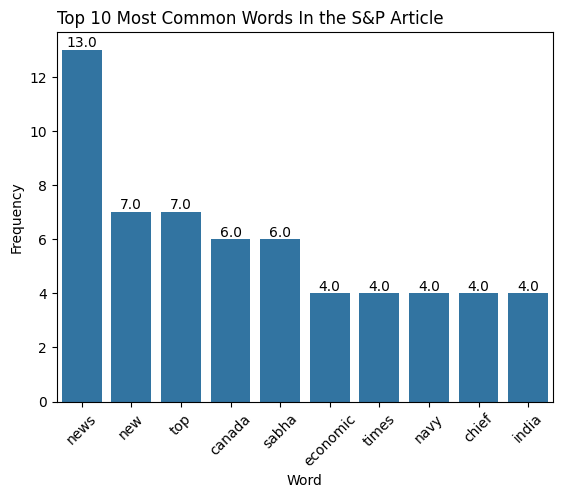

In [ ]:
# Take all paragraphs for the Nasdaq article, convert it into a corpus and get basic statistics
import string
# Step 1: Extract text from paragraph tags

paragraphs = soup.find_all('p')
text_list = [p.get_text(strip=True) for p in paragraphs]

# Step 2: Combine paragraphs into a single document
sp_full = " ".join(text_list)

# Step 3: Work directly with the tokens
import os
from nltk.corpus import PlaintextCorpusReader

## Save to a local text file
with open("sp_article.txt", "w", encoding="utf-8") as f:
    f.write(sp_full)

## Create a corpus folder (optional)
corpus_root = './'
corpus = PlaintextCorpusReader(corpus_root, 'sp_article.txt')

## Now, check the stopwords
words = corpus.words()
print(words[:30])

# Step 4: Tokenize
tokens = word_tokenize(sp_full)

# Step 5: Convert all tokens to lowercase, remove stopwords and puncutation
stop_words = set(stopwords.words("english"))
punct = set(string.punctuation)

# Step 5a: create the clean_tokens list
clean_tokens = [
    t.lower() for t in tokens
    if t.lower() not in stop_words and t not in punct and t.isalpha()
]

# Step 6: Count word frequencies
freqs = Counter(clean_tokens)

# Step 7: Get the top 10 most freuqent words and perform EDA
sp_top_10 = freqs.most_common(10)

print(sp_top_10)

# Get the top 10 words into a pandas dataframe for data visualization
sp_df = pd.DataFrame(sp_top_10, columns=['Word', 'Frequency'])

# Create a bar plot of the 10 most common words
ax = sns.barplot(x='Word', y='Frequency', data=sp_df)

# Rotate the x-axis labels for easier reading
ax.tick_params(axis='x', rotation=45)

# Add data labels
for a in ax.patches:
    ax.annotate(f'{a.get_height()}',
                (a.get_x() + a.get_width() / 2., a.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')

plt.title('Top 10 Most Common Words In the S&P Article', loc='left')
plt.show()

## Russel 2k Text Mining

In [ ]:
russel = urllib.request.urlopen('https://economictimes.indiatimes.com/news/international/us/russell-2000-index-of-small-cap-stocks-are-struggling-against-sp-500-dow-jones-nasdaq-heres-why/articleshow/125509409.cms?from=mdr').read()
soup = bs.BeautifulSoup(russel, 'lxml') # object and parser

print(soup)
print(soup.title) # Print the title...notice the tags

print(soup.title.string) # Print just the title string

print(soup.title.text)

# Now...try getting specific values

# First, get the paragraph
print("--Paragraph (w/ Tags)--")
print(soup.p)
# Now, get the paragraph text
print("\n--Paragraph Text--")
print(soup.p.text)

# Now, get all paragraphs
print("\n--All Paragraphs--")
print(soup.find_all('p'))

<!DOCTYPE html>
<html class="no-js" lang="en"><head><meta content="text/html; charset=utf-8" http-equiv="Content-Type"/><title>Russell 2000 index of small-cap stocks are struggling against S&amp;P 500, Dow Jones, Nasdaq. Worrying signs for small companies in U.S.? - The Economic Times</title><meta content="Small-cap Russell 2000 index fell for a fourth straight week in its longest run of weekly losses since March." name="description"/><meta content="Russell 2000 index,S&amp;P 500,Nasdaq,U.S. Stock Market,Dow Jones,small-cap stocks" name="news_keywords"/><meta content="Russell 2000 index,S&amp;P 500,Nasdaq,U.S. Stock Market,Dow Jones,small-cap stocks" name="keywords"/><meta content="Russell 2000 index" property="article:tag"/><meta content="S&amp;P 500" property="article:tag"/><meta content="Nasdaq" property="article:tag"/><meta content="U.S. Stock Market" property="article:tag"/><meta content="Dow Jones" property="article:tag"/><script>
		    var boomrScriptUrl = window.location.href.i

['Small', '-', 'cap', 'Russell', '2000', 'index', 'fell', 'for', 'a', 'fourth', 'straight', 'week', 'in', 'its', 'longest', 'run', 'of', 'weekly', 'losses', 'since', 'March', '.', 'Listen', 'to', 'this', 'article', 'in', 'summarized', 'format', 'Unlock']
[('news', 13), ('pm', 8), ('modi', 8), ('india', 6), ('calls', 6), ('top', 6), ('canada', 4), ('economic', 4), ('times', 4), ('anunay', 4)]


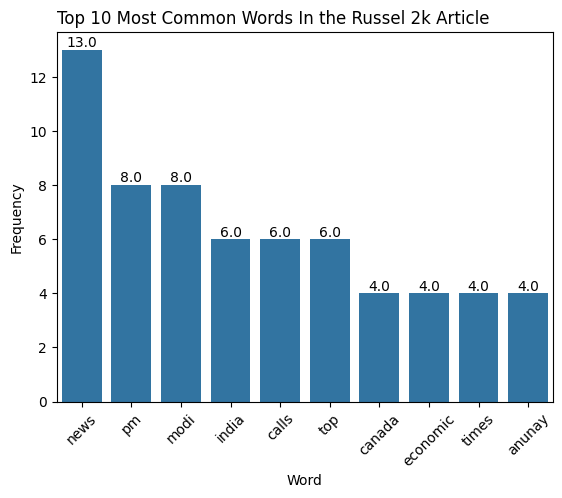

In [ ]:
# Take all paragraphs for the Nasdaq article, convert it into a corpus and get basic statistics
import string
# Step 1: Extract text from paragraph tags

paragraphs = soup.find_all('p')
text_list = [p.get_text(strip=True) for p in paragraphs]

# Step 2: Combine paragraphs into a single document
russel_full = " ".join(text_list)

# Step 3: Work directly with the tokens
import os
from nltk.corpus import PlaintextCorpusReader

## Save to a local text file
with open("russel_article.txt", "w", encoding="utf-8") as f:
    f.write(russel_full)

## Create a corpus folder (optional)
corpus_root = './'
corpus = PlaintextCorpusReader(corpus_root, 'russel_article.txt')

## Now, check the stopwords
words = corpus.words()
print(words[:30])

# Step 4: Tokenize
tokens = word_tokenize(russel_full)

# Step 5: Convert all tokens to lowercase, remove stopwords and puncutation
stop_words = set(stopwords.words("english"))
punct = set(string.punctuation)

# Step 5a: create the clean_tokens list
clean_tokens = [
    t.lower() for t in tokens
    if t.lower() not in stop_words and t not in punct and t.isalpha()
]

# Step 6: Count word frequencies
freqs = Counter(clean_tokens)

# Step 7: Get the top 10 most freuqent words and perform EDA
russel_top_10 = freqs.most_common(10)

print(russel_top_10)

# Get the top 10 words into a pandas dataframe for data visualization
russel_df = pd.DataFrame(russel_top_10, columns=['Word', 'Frequency'])

# Create a bar plot of the 10 most common words
ax = sns.barplot(x='Word', y='Frequency', data=russel_df)

# Rotate the x-axis labels for easier reading
ax.tick_params(axis='x', rotation=45)

# Add data labels
for a in ax.patches:
    ax.annotate(f'{a.get_height()}',
                (a.get_x() + a.get_width() / 2., a.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')

plt.title('Top 10 Most Common Words In the Russel 2k Article', loc='left')
plt.show()

# Sentiment Analysis

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
#function to score article text
def get_sentiment(text):
    if text is None or len(str(text).strip()) == 0:
        return None
    return sia.polarity_scores(text)

In [ ]:
sentiment_results = {
    "Dow Jones": get_sentiment(dow_full),
    "Nasdaq": get_sentiment(nasdaq_full),
    "S&P 500": get_sentiment(sp_full),
    "Russell 2000": get_sentiment(russel_full)
}

In [ ]:
import pandas as pd

sentiment_df = pd.DataFrame(sentiment_results).T
sentiment_df


,neg,neu,pos,compound
Dow Jones,0.040,0.877,0.082,0.9900
Nasdaq,0.026,0.875,0.099,0.9922
S&P 500,0.078,0.802,0.120,0.9819
Russell 2000,0.109,0.785,0.106,-0.7739


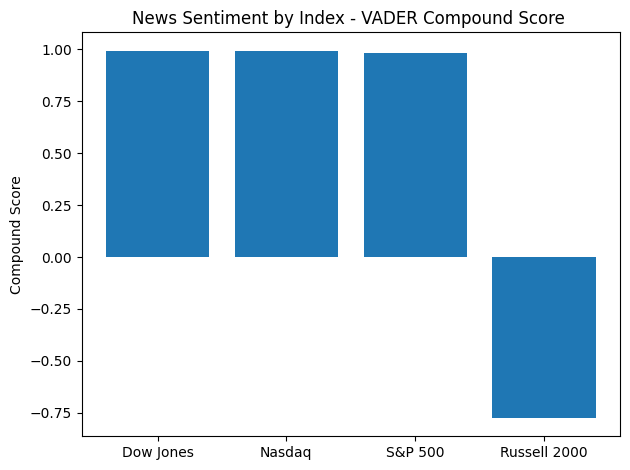

,neg,neu,pos,compound,label,net_sentiment
Dow Jones,0.040,0.877,0.082,0.9900,Positive,0.042
Nasdaq,0.026,0.875,0.099,0.9922,Positive,0.073
S&P 500,0.078,0.802,0.120,0.9819,Positive,0.042
Russell 2000,0.109,0.785,0.106,-0.7739,Negative,-0.003


In [ ]:
# Extra analysis to enrich sentiment results

# Add a simple sentiment label for easier interpretation
def label_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

sentiment_df["label"] = sentiment_df["compound"].apply(label_sentiment)

# Create a net sentiment metric (positive minus negative)
sentiment_df["net_sentiment"] = sentiment_df["pos"] - sentiment_df["neg"]

#  Rank indices by sentiment strength
sentiment_ranked = sentiment_df.sort_values("compound", ascending=False)

#  Quick visualization of compound scores
import matplotlib.pyplot as plt

plt.figure()
plt.bar(sentiment_df.index, sentiment_df["compound"])
plt.title("News Sentiment by Index - VADER Compound Score ")
plt.ylabel("Compound Score")
plt.xticks()
plt.tight_layout()
plt.show()

# updated table with extra columns
sentiment_df